# **Business Analytics Project on Football Dataset**
* This dataset contains historical data of football games for the past 25 years
* Detailed descriptions of features available at https://github.com/xgabora/Club-Football-Match-Data-2000-2025/blob/main/README.md
* **Disclaimer:** The ideas and implementation of the analyses throughout this project are all my own. However, I did take AI help to make the code efficient in some parts and to discover ways to effectively implement some of the tricky ideas I came up with.

# **Importing libraries and loading the dataset**



In [337]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [338]:
df = pd.read_csv('https://github.com/xgabora/Club-Football-Match-Data-2000-2025/raw/refs/heads/main/data/Matches.csv')

/tmp/ipython-input-944986267.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://github.com/xgabora/Club-Football-Match-Data-2000-2025/raw/refs/heads/main/data/Matches.csv')


# **In this section we will take a look at the dataset and identify potential issues**



In [339]:
df.head()

,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,MaxUnder25,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB
0,F1,2000-07-28,NaN,Marseille,Troyes,1686.34,1586.57,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F1,2000-07-28,NaN,Paris SG,Strasbourg,1714.89,1642.51,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F2,2000-07-28,NaN,Wasquehal,Nancy,1465.08,1633.80,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F1,2000-07-29,NaN,Auxerre,Sedan,1635.58,1624.22,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F1,2000-07-29,NaN,Bordeaux,Metz,1734.34,1673.11,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [340]:
print(df.columns)
print(df.shape)

Index(['Division', 'MatchDate', 'MatchTime', 'HomeTeam', 'AwayTeam', 'HomeElo',
       'AwayElo', 'Form3Home', 'Form5Home', 'Form3Away', 'Form5Away', 'FTHome',
       'FTAway', 'FTResult', 'HTHome', 'HTAway', 'HTResult', 'HomeShots',
       'AwayShots', 'HomeTarget', 'AwayTarget', 'HomeFouls', 'AwayFouls',
       'HomeCorners', 'AwayCorners', 'HomeYellow', 'AwayYellow', 'HomeRed',
       'AwayRed', 'OddHome', 'OddDraw', 'OddAway', 'MaxHome', 'MaxDraw',
       'MaxAway', 'Over25', 'Under25', 'MaxOver25', 'MaxUnder25', 'HandiSize',
       'HandiHome', 'HandiAway', 'C_LTH', 'C_LTA', 'C_VHD', 'C_VAD', 'C_HTB',
       'C_PHB'],
      dtype='object')
(230557, 48)


It appears that we have 48 different columns with some technical ones

In [341]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230557 entries, 0 to 230556
Data columns (total 48 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Division     230557 non-null  object 
 1   MatchDate    230557 non-null  object 
 2   MatchTime    99072 non-null   object 
 3   HomeTeam     230557 non-null  object 
 4   AwayTeam     230557 non-null  object 
 5   HomeElo      141597 non-null  float64
 6   AwayElo      141528 non-null  float64
 7   Form3Home    229057 non-null  float64
 8   Form5Home    229057 non-null  float64
 9   Form3Away    229057 non-null  float64
 10  Form5Away    229057 non-null  float64
 11  FTHome       230554 non-null  float64
 12  FTAway       230554 non-null  float64
 13  FTResult     230554 non-null  object 
 14  HTHome       175977 non-null  float64
 15  HTAway       175977 non-null  float64
 16  HTResult     175977 non-null  object 
 17  HomeShots    114735 non-null  float64
 18  AwayShots    114738 non-

In [342]:
# Calculating % of missing values in each column
total_rows = len(df)
missing_data = df.isnull().sum()
missing_percentage = (missing_data / total_rows) * 100
missing_percentage

,0
Division,0.000000
MatchDate,0.000000
MatchTime,57.029281
HomeTeam,0.000000
AwayTeam,0.000000
HomeElo,38.584819
AwayElo,38.614746
Form3Home,0.650598
Form5Home,0.650598
Form3Away,0.650598


Observations


*   MatchDate is not in datetime format
*   Many missing values given the diversity of the dataset
*   The last 6 columns deal with very technical values that is not available for many of the teams
*   Some additional columns may help us understand the data better

# **Data Cleaning (For exploratory data analysis)**

In [343]:
# Drop last six columns and some other technical columns with high levels of missing values.
# We also remove some columns not relevant to for our analysis like Over25 that include betting odds for over 2.5 goals in the game
columns_to_drop = ['C_LTH', 'C_LTA', 'C_VHD', 'C_VAD', 'C_HTB', 'C_PHB', 'HandiHome', 'HandiAway',
                   'HandiSize', 'MaxUnder25', 'MaxOver25', 'Under25', 'Over25']
df = df.drop(columns=columns_to_drop)
df

,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,HomeYellow,AwayYellow,HomeRed,AwayRed,OddHome,OddDraw,OddAway,MaxHome,MaxDraw,MaxAway
0,F1,2000-07-28,NaN,Marseille,Troyes,1686.34,1586.57,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1.65,3.30,4.30,NaN,NaN,NaN
1,F1,2000-07-28,NaN,Paris SG,Strasbourg,1714.89,1642.51,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1.60,3.40,4.60,NaN,NaN,NaN
2,F2,2000-07-28,NaN,Wasquehal,Nancy,1465.08,1633.80,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F1,2000-07-29,NaN,Auxerre,Sedan,1635.58,1624.22,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1.70,3.30,3.90,NaN,NaN,NaN
4,F1,2000-07-29,NaN,Bordeaux,Metz,1734.34,1673.11,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1.65,3.30,4.30,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230552,SP2,2025-06-01,17:30:00,Cartagena,Mirandes,1339.21,1544.15,3.0,6.0,7.0,...,3.0,1.0,0.0,0.0,12.33,6.19,1.20,15.00,7.00,1.22
230553,SP2,2025-06-01,17:30:00,Almeria,Tenerife,1544.16,1433.67,4.0,10.0,1.0,...,1.0,5.0,0.0,0.0,1.22,6.23,10.97,1.24,6.75,13.00
230554,SP2,2025-06-01,17:30:00,La Coruna,Elche,1473.67,1569.98,0.0,3.0,3.0,...,2.0,2.0,0.0,0.0,5.30,4.43,1.52,6.10,4.60,1.56
230555,SP2,2025-06-01,17:30:00,Oviedo,Cadiz,1574.90,1525.76,7.0,13.0,6.0,...,0.0,1.0,0.0,0.0,1.68,3.14,6.31,1.72,3.25,7.20


In [344]:
# We convert matchdate to datetime format
df['MatchDate'] = pd.to_datetime(df['MatchDate'])
print(df['MatchDate'].dtype)
df[['MatchDate']].head()

datetime64[ns]


,MatchDate
0,2000-07-28
1,2000-07-28
2,2000-07-28
3,2000-07-29
4,2000-07-29


In [345]:
# We add Elo Difference column to check the difference in strength between teams
df['EloDiff'] = df['HomeElo'] - df['AwayElo']

# We add a column to see difference in number of points in last 3 matches
df['Form3Diff'] = df['Form3Home'] - df['Form3Away']

# We add a column to see difference in number of points in last 5 matches
df['Form5Diff'] = df['Form5Home'] - df['Form5Away']

df

,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,AwayRed,OddHome,OddDraw,OddAway,MaxHome,MaxDraw,MaxAway,EloDiff,Form3Diff,Form5Diff
0,F1,2000-07-28,NaN,Marseille,Troyes,1686.34,1586.57,0.0,0.0,0.0,...,NaN,1.65,3.30,4.30,NaN,NaN,NaN,99.77,0.0,0.0
1,F1,2000-07-28,NaN,Paris SG,Strasbourg,1714.89,1642.51,0.0,0.0,0.0,...,NaN,1.60,3.40,4.60,NaN,NaN,NaN,72.38,0.0,0.0
2,F2,2000-07-28,NaN,Wasquehal,Nancy,1465.08,1633.80,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-168.72,0.0,0.0
3,F1,2000-07-29,NaN,Auxerre,Sedan,1635.58,1624.22,0.0,0.0,0.0,...,NaN,1.70,3.30,3.90,NaN,NaN,NaN,11.36,0.0,0.0
4,F1,2000-07-29,NaN,Bordeaux,Metz,1734.34,1673.11,0.0,0.0,0.0,...,NaN,1.65,3.30,4.30,NaN,NaN,NaN,61.23,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230552,SP2,2025-06-01,17:30:00,Cartagena,Mirandes,1339.21,1544.15,3.0,6.0,7.0,...,0.0,12.33,6.19,1.20,15.00,7.00,1.22,-204.94,-4.0,-7.0
230553,SP2,2025-06-01,17:30:00,Almeria,Tenerife,1544.16,1433.67,4.0,10.0,1.0,...,0.0,1.22,6.23,10.97,1.24,6.75,13.00,110.49,3.0,7.0
230554,SP2,2025-06-01,17:30:00,La Coruna,Elche,1473.67,1569.98,0.0,3.0,3.0,...,0.0,5.30,4.43,1.52,6.10,4.60,1.56,-96.31,-3.0,-4.0
230555,SP2,2025-06-01,17:30:00,Oviedo,Cadiz,1574.90,1525.76,7.0,13.0,6.0,...,0.0,1.68,3.14,6.31,1.72,3.25,7.20,49.14,1.0,4.0


In [346]:
# we remove columns with missing values of less than 2%

columns_below_2percent_na = missing_percentage[missing_percentage < 2].index
df = df.dropna(subset=columns_below_2percent_na)

In [347]:
df.isnull().sum()/len(df) * 100

,0
Division,0.000000
MatchDate,0.000000
MatchTime,56.737422
HomeTeam,0.000000
AwayTeam,0.000000
HomeElo,38.626148
AwayElo,38.659329
Form3Home,0.000000
Form5Home,0.000000
Form3Away,0.000000


# **Data Manipulation**

I will filter and manipulate the data to fit my needs

In [348]:
df['Division'].unique()

array(['F1', 'D1', 'D2', 'B1', 'E1', 'N1', 'P1', 'E0', 'E2', 'SP1', 'I1',
       'I2', 'SP2', 'T1', 'F2', 'E3', 'SC0', 'SC1', 'SC2', 'SC3', 'G1',
       'EC', 'USA', 'SWE', 'NOR', 'IRL', 'BRA', 'ARG', 'MEX', 'JAP',
       'RUS', 'POL', 'DEN', 'ROM', 'AUT', 'SUI', 'FIN', 'CHN'],
      dtype=object)

* I will filter for main leagues because smaller leagues often lack data (0/1 indicate top leagues in the country)
* Additionally I filtered for each league in excel to get a comprehensive feel of the data and to find out leagues from team names at a glance
* We will explore some time based trends in exploratory analysis so we will only pick leagues that have data from the same times here
* For modeling we will include data from other time periods as well because we don't consider time then

In [349]:
# dataset for exploratory analysis (We will create the modeling dataset later)
exploratory_divisions = ['F1', 'D1', 'E1', 'N1', 'P1', 'E0', 'SP1', 'I1', 'T1', 'SC0', 'G1']
df_exploratory = df[df['Division'].isin(exploratory_divisions)]

In [350]:
df_exploratory.shape

(86249, 38)

In [351]:
missing_percentage_2 = df_exploratory.isnull().sum()/len(df_exploratory) * 100
missing_percentage_2

,0
Division,0.000000
MatchDate,0.000000
MatchTime,74.878549
HomeTeam,0.000000
AwayTeam,0.000000
HomeElo,1.536250
AwayElo,1.532771
Form3Home,0.000000
Form5Home,0.000000
Form3Away,0.000000


In [352]:
# We remove the columns with missing values not relevant for our analysis

columns_to_drop_2 = ['HomeShots', 'AwayShots', 'HomeTarget', 'AwayTarget', 'HomeFouls',
                     'AwayFouls', 'HomeCorners', 'AwayCorners', 'HomeYellow', 'AwayYellow', 'MatchTime']
df_exploratory = df_exploratory.drop(columns=columns_to_drop_2)

In [353]:
# We also rows in columns having less than 4% missing values
columns_below_2percent_na_2 = missing_percentage_2[missing_percentage_2 < 4].index
df_exploratory = df_exploratory.dropna(subset=columns_below_2percent_na_2)

In [354]:
df_exploratory.shape

(83637, 27)

In [355]:
# We also add a total goals scored column to aid our analysis
# FTHome shows home team goals at full time and FTAway shows away team goals at full time

df_exploratory['TotalGoals'] = df_exploratory['FTHome'] + df_exploratory['FTAway']

In [356]:
df_exploratory.isnull().sum()/len(df_exploratory) * 100

,0
Division,0.000000
MatchDate,0.000000
HomeTeam,0.000000
AwayTeam,0.000000
HomeElo,0.000000
AwayElo,0.000000
Form3Home,0.000000
Form5Home,0.000000
Form3Away,0.000000
Form5Away,0.000000


The dataset is now fit for our exploratory data analysis as the null value columns will not be required by our analysis

# **Exploratory Data Analysis**

**Questions to explore**


1.   Difference in average goals across divisions
  * We can explore if some leagues are more competitive than others
2. Checking ELO of major leagues over the past 25 years
3. Checking how winning at home is related to different features
4. Checking distribution of goals accross major leagues and finding outliers and memorable games
5.   Manchester United’s performance over the last 25 years
  * As a lifelong Manchester United fan, I want to see how the team has developed over the years
  * We explore how Manchester United's goal scoring records have developed when compared to the Premier League as a whole

#1.   Difference in average goals across divisions


In [357]:
# We first group by division and calculate mean
avg_goals_by_division = df_exploratory.groupby('Division')['TotalGoals'].mean().round(2).sort_values(ascending=False)

In [358]:
avg_goals_by_division

,TotalGoals
Division,
N1,3.06
D1,2.95
T1,2.79
E0,2.72
I1,2.68
SP1,2.67
SC0,2.67
E1,2.56
P1,2.52


/tmp/ipython-input-3179738881.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_goals_by_division.index, y=avg_goals_by_division, palette='viridis')


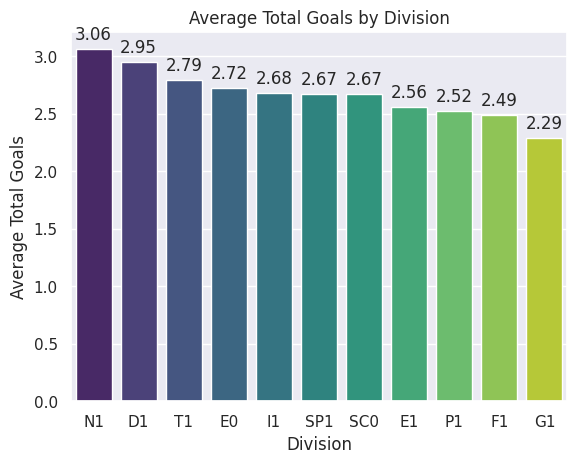

In [359]:
# Now we create the barplot in seaborn. We will use the viridis palette to make the visualizations look better
sns.barplot(x=avg_goals_by_division.index, y=avg_goals_by_division, palette='viridis')
plt.title('Average Total Goals by Division')
plt.xlabel('Division')
plt.ylabel('Average Total Goals')

# We add labels above each bar. ha and va parameters are for alignment
for i, v in enumerate(avg_goals_by_division):
    plt.text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom')

From the barplot it is evident that there is a significant difference in average goals scored in a match accross different leagues. N1 (Eredivisie), the primary league in Netherlands appears to be the most competititive in terms of average goals seen in a match while G1, the primary league in Greece, seems to be the least competitive in terms of goals. E0, The English Premier League sits at a relatively high 2.72 average goals per match.

#2. line chart of average elo per year of major divisions across the 25 years

In [360]:
# We need to add a average ELO per match column by aggreating Home and Away ELO
df_exploratory['AvgElo'] = (df_exploratory['HomeElo'] + df_exploratory['AwayElo']) / 2

In [361]:
# We extract year values from the matchdate column
df_exploratory['Year'] = df_exploratory['MatchDate'].dt.year

In [362]:
# We subset the dataset to keep only the big 5 football leagues

major_divisions = ['F1', 'SP1', 'E0', 'D1', 'I1']
df_major = df_exploratory[df_exploratory['Division'].isin(major_divisions)]

In [363]:
# To make the chart more readable I will use the full Division names in this subset

division_mapping = {
    'F1': 'French Ligue 1', 'SP1': 'Spanish La Liga',
    'E0': 'English Premier League','D1': 'German Bundesliga',
    'I1': 'Italian Serie A'
}

df_major['Division'] = df_major['Division'].map(division_mapping)

/tmp/ipython-input-1599223279.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_major['Division'] = df_major['Division'].map(division_mapping)


In [364]:
# Now we group by year and division and find the means
avg_elo_by_year_div = df_major.groupby(['Year', 'Division'])['AvgElo'].mean().reset_index()

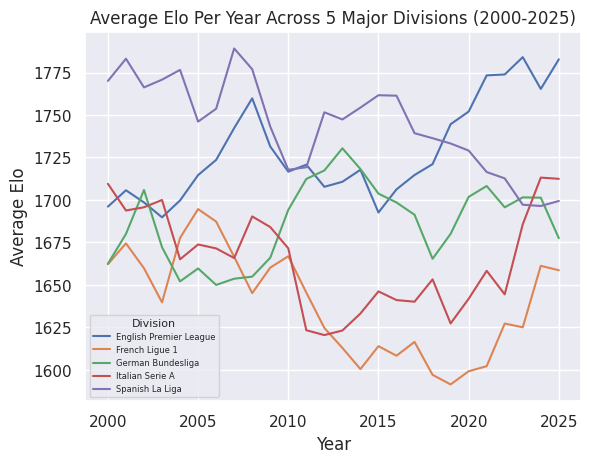

In [365]:
sns.set_theme(style='darkgrid')

sns.lineplot(data=avg_elo_by_year_div, x='Year', y='AvgElo', hue='Division')
plt.title('Average Elo Per Year Across 5 Major Divisions (2000-2025)')
plt.xlabel('Year')
plt.ylabel('Average Elo')
plt.legend(title='Division', title_fontsize=8, fontsize=6)
plt.xticks(range(2000, 2026, 5))
plt.show()

We have some fascinating observations here.
It seems that back in the early 2000s, La Liga dominated the football scene with the presence of strongest teams (By Elo) in league. This seems to align with my football knowledge as global superstars like Zidane, Ronaldinho and Ronaldo (R9) all played in La Liga in that period.

* The rest of the major leagues were at similar levels all below La Liga.
* Ligue 1 has consistently had low average Elo levels
* The rise of the English Premier League has been significant and it is the strongest league in the world by Elo currently. This is in line with its popularity as even Bangladesh has developed a massive EPL fanbase over the recent years.
* This is further corroborated by the competitiveness in EPL. La Liga has fallen in recent years as only 3/4 teams dominate the league table. While in the EPL the top 7/8 teams all are competiting for the major trophies. Even Tottenham, a team 17th in the EPL league table, won the Europa league ahead of major teams in other leagues.

#3. Correlation between HomeWin and significant numerical columns

In [366]:
# First we map the FTresult column into HomeWin into numerical values where win = 1 and draws and losses are equal to 0
df_exploratory['HomeWin'] = df_exploratory['FTResult'].map({'H': 1, 'D': 0, 'A': 0})

In [367]:
# Now we check the correlation between different numerical columns
correlation_cols = ['Form3Diff', 'Form5Diff', 'EloDiff', 'HTHome', 'HTAway', 'HomeWin']
df_correlation = df_exploratory[correlation_cols]
correlation_matrix = df_correlation.corr()

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5]),
 [Text(0, 0.5, 'Form3Diff'),
  Text(0, 1.5, 'Form5Diff'),
  Text(0, 2.5, 'EloDiff'),
  Text(0, 3.5, 'HTHome'),
  Text(0, 4.5, 'HTAway'),
  Text(0, 5.5, 'HomeWin')])

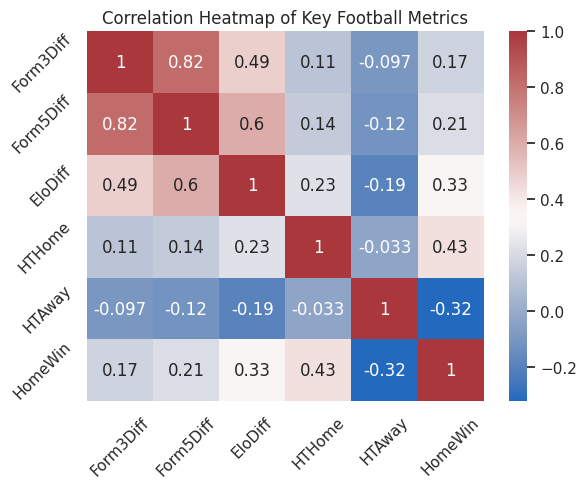

In [368]:
sns.heatmap(correlation_matrix, annot=True, cmap='vlag')
plt.title('Correlation Heatmap of Key Football Metrics')
plt.xticks(rotation=45)
plt.yticks(rotation=45)

From the heatmap we get the following insights
* HomeWin is moderately correlated with EloDiff, indicating that having a higher elo difference than the away team can be correlated to the home team winning
* HTHome (Home team goals at half time) has a decent positive correlation with winning and HTAway (Away team goals at half time) has a negative correlation. Indicating that home teams that score half time have a higher chance of getting a win
* We also see correlation between forms over last 3 and 5 matches with the correlation between form over 5 days being higher. Indicating that teams that have had better form over 5 days may be more poised to win

#4. Distribution of goals across major leagues and outliers

/tmp/ipython-input-1538224679.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_major, x='Division', y='TotalGoals', palette='viridis')


([0, 1, 2, 3, 4],
 [Text(0, 0, 'French Ligue 1'),
  Text(1, 0, 'German Bundesliga'),
  Text(2, 0, 'English Premier League'),
  Text(3, 0, 'Spanish La Liga'),
  Text(4, 0, 'Italian Serie A')])

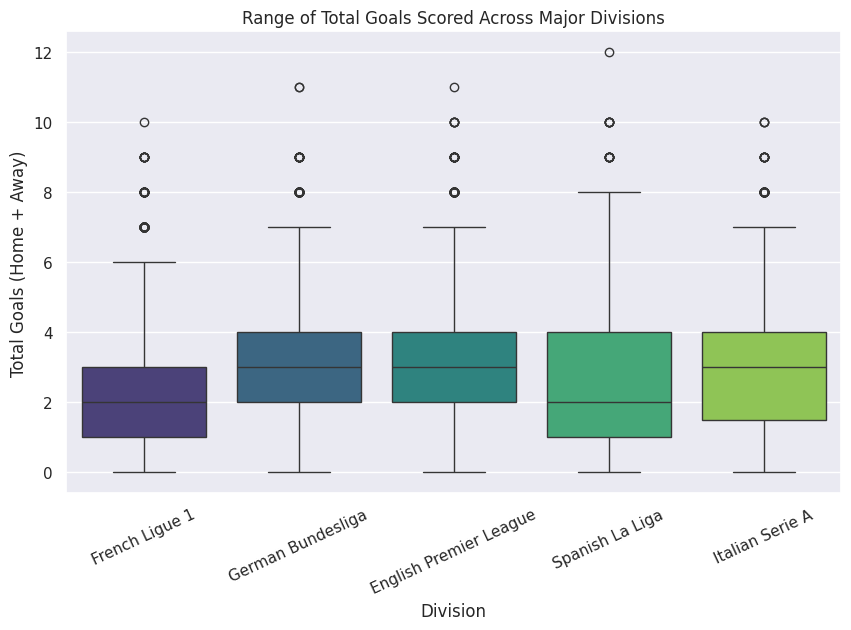

In [369]:
# We create a boxplot to see how man
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_major, x='Division', y='TotalGoals', palette='viridis')
plt.title('Range of Total Goals Scored Across Major Divisions')
plt.xlabel('Division')
plt.ylabel('Total Goals (Home + Away)')
plt.xticks(rotation=25)

In [370]:
df_major.groupby('Division')['TotalGoals'].describe()

,count,mean,std,min,25%,50%,75%,max
Division,,,,,,,,
English Premier League,9325.0,2.717748,1.667860,0.0,2.0,3.0,4.0,11.0
French Ligue 1,8630.0,2.493395,1.594809,0.0,1.0,2.0,3.0,10.0
German Bundesliga,7447.0,2.949107,1.717791,0.0,2.0,3.0,4.0,11.0
Italian Serie A,8891.0,2.677877,1.649673,0.0,1.5,3.0,4.0,10.0
Spanish La Liga,8918.0,2.674591,1.682479,0.0,1.0,2.0,4.0,12.0


Observations of range of goals across the top 5 leagues
* French league seems to be at the bottom in terms of average goals in a match. This corresponds to their low Elo over the years as well
* La Liga has the highest diversity in terms total goals in a match with a high IQR of around 2. But, the boxplot is positively skewed, indicating most games end in a relatively low score
* The rest of the leagues seem to be similar similar in this regard
* We have some outliers which can be traced back to some iconic games like the highest scoring EPL game where Portsmouth and Reading shared 11 goals back in 2007

Text(-11.430555555555548, 0.5, 'Count')

<Figure size 1200x600 with 0 Axes>

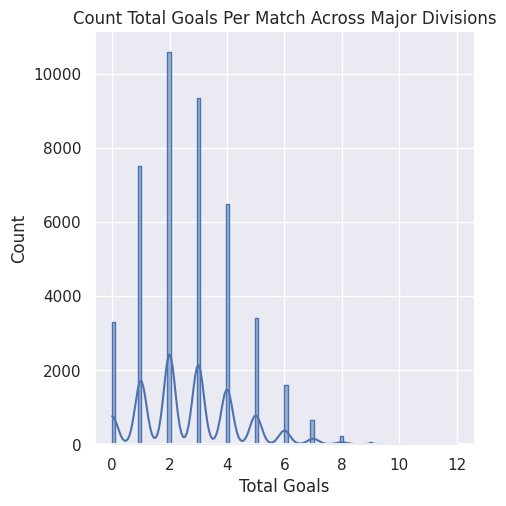

In [371]:
plt.figure(figsize=(12, 6))

sns.displot(data=df_major, x='TotalGoals', element='step', kde=True)
plt.title('Count Total Goals Per Match Across Major Divisions')
plt.xlabel('Total Goals')
plt.ylabel('Count')

* A barchart of TotalGoals across the 5 major leagues further reveals that most games have historically ended with 2 goals among the teams

#5. Trends related to Manchester United
* As a lifelong Manchester United fan, I wanted to see how Manchester United has been performing over the years

In [372]:
# We subset the dataset and pick only Manchester United from E0 (The English Premier League)
df_manu = df_major[(df_major['HomeTeam'] == 'Man United') | (df_major['AwayTeam'] == 'Man United')]

In [373]:
# We subset data for Man City as well to see how Man United performed when compared to their rival
df_city = df_major[(df_major['HomeTeam'] == 'Man City') | (df_major['AwayTeam'] == 'Man City')]

In [374]:
# Now we create a column for the Elo for Man United which has the Elo of Man United only from home and away games
df_manu['manu_elo'] = 0
for index, row in df_manu.iterrows():
    if row['HomeTeam'] == 'Man United':
        df_manu.loc[index, 'manu_elo'] = row['HomeElo']
    else:
        df_manu.loc[index, 'manu_elo'] = row['AwayElo']

/tmp/ipython-input-1373692563.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_manu['manu_elo'] = 0
/tmp/ipython-input-1373692563.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1931.95' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_manu.loc[index, 'manu_elo'] = row['HomeElo']


In [375]:
# We create elo column for man city elo in their dataset
df_city['city_elo'] = 0
for index, row in df_city.iterrows():
    if row['HomeTeam'] == 'Man City':
        df_city.loc[index, 'city_elo'] = row['HomeElo']
    else:
        df_city.loc[index, 'city_elo'] = row['AwayElo']

/tmp/ipython-input-1659509310.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_city['city_elo'] = 0
/tmp/ipython-input-1659509310.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1579.99' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_city.loc[index, 'city_elo'] = row['AwayElo']


In [376]:
# We take a look if the new column is  correctly created
df_manu.head()

,Division,MatchDate,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,Form5Away,...,MaxHome,MaxDraw,MaxAway,EloDiff,Form3Diff,Form5Diff,TotalGoals,AvgElo,Year,manu_elo
220,English Premier League,2000-08-20,Man United,Newcastle,1931.95,1712.19,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,219.76,0.0,0.0,2.0,1822.070,2000,1931.95
225,English Premier League,2000-08-22,Ipswich,Man United,1638.08,1931.95,0.0,0.0,9.0,15.0,...,NaN,NaN,NaN,-293.87,-9.0,-15.0,2.0,1785.015,2000,1931.95
262,English Premier League,2000-08-26,West Ham,Man United,1681.36,1931.95,0.0,0.0,6.0,10.0,...,NaN,NaN,NaN,-250.59,-6.0,-10.0,4.0,1806.655,2000,1931.95
412,English Premier League,2000-09-05,Man United,Bradford,1927.83,1596.85,5.0,8.0,4.0,7.0,...,NaN,NaN,NaN,330.98,1.0,1.0,6.0,1762.340,2000,1927.83
526,English Premier League,2000-09-09,Man United,Sunderland,1927.83,1704.21,5.0,10.0,1.0,5.0,...,NaN,NaN,NaN,223.62,4.0,5.0,3.0,1816.020,2000,1927.83


Text(0, 0.5, 'Average Elo Rating')

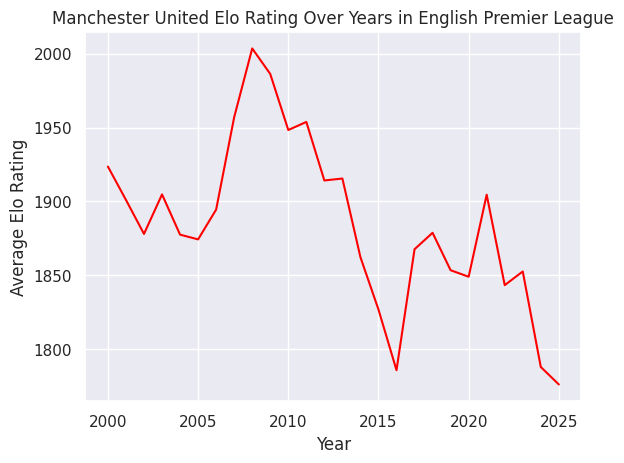

In [377]:
manu_elo_by_year = df_manu.groupby('Year')['manu_elo'].mean().reset_index()
sns.lineplot(data=manu_elo_by_year, x='Year', y='manu_elo',color='red')
plt.title('Manchester United Elo Rating Over Years in English Premier League')
plt.xlabel('Year')
plt.ylabel('Average Elo Rating')

The Elo trend is in line with the results Manchester United has seen over the years.
* The Elo levels of Man United peaked around 2007 and 2008. This was when Man United had players like Rooney, Tevez, Cristiano Ronaldo and Scholes playing together. It was also around this time when Manchester United won the Champions League in 2008, marking their dominance in this era.
* The steep decline in Elo around 2013 is when Sir Alex Ferguson left his managerial role at Man United after 26 years. The sudden change in manager was a big shock for the team and we have not yet quite recovered.
* The absolute low in 2025 is characterized by the fact that Manchester United has had their lowest league position (16th) in the history of the league in 2025

Text(0, 0.5, 'Average Elo Rating')

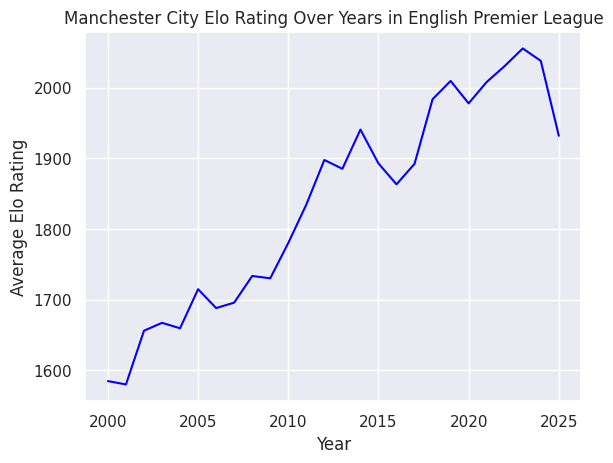

In [378]:
city_elo_by_year = df_city.groupby('Year')['city_elo'].mean().reset_index()
sns.lineplot(data=city_elo_by_year, x='Year', y='city_elo', color='blue')
plt.title('Manchester City Elo Rating Over Years in English Premier League')
plt.xlabel('Year')
plt.ylabel('Average Elo Rating')

* The story is very different when it comes to Man City, lifelong rivals of Manchester United. They have seen a meteoric rise in terms of strength.
* The have seen their peak strength between 2020 and 2024 before seeing a dip in 2025. This can be attributed to the fact that Manchester City won 4 consecutive Premier League titles between 2020 and 2024, but finally lost to Liverpool in 2025

In [379]:
# We see if there is any trend in average goals scored per season for Man United
df_manu['ManUtdGoals'] = 0
for index, row in df_manu.iterrows():
    if row['HomeTeam'] == 'Man United':
        df_manu.loc[index, 'ManUtdGoals'] = row['FTHome']
    elif row['AwayTeam'] == 'Man United':
        df_manu.loc[index, 'ManUtdGoals'] = row['FTAway']

/tmp/ipython-input-1359173603.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_manu['ManUtdGoals'] = 0


In [380]:
goals_by_year = df_manu.groupby('Year')['ManUtdGoals'].mean().reset_index()

/tmp/ipython-input-2286025146.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=goals_by_year, x='Year', y='ManUtdGoals', palette = 'viridis')


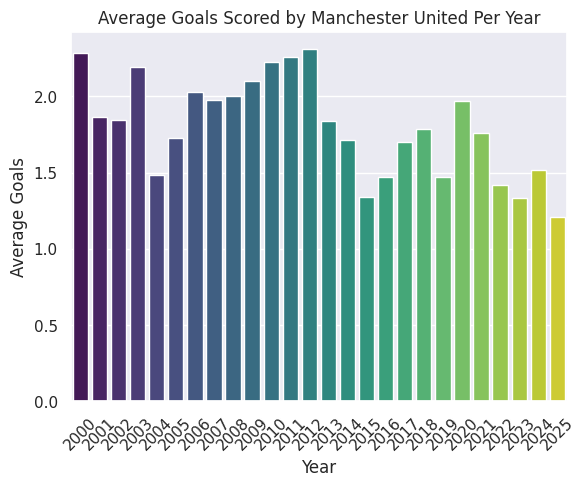

In [381]:
sns.barplot(data=goals_by_year, x='Year', y='ManUtdGoals', palette = 'viridis')
plt.title('Average Goals Scored by Manchester United Per Year')
plt.xlabel('Year')
plt.ylabel('Average Goals')
plt.xticks(rotation=45)
plt.show()

Looking at a bar chart of average goals scored over the years. It seems that the goal output of Manchester United was dropping in the last years of Sir Alex beginning in 2012, indicating that there might be deeper issues than just the manager leaving. But the situation did not improve much and Manchester United saw one of their lowest scoring seasons in 2025

# Manchester United vs The Premier League Goal Trend

---



* We compare trend of goals in the premier league over the years with that of Manchester United's
* We add Total Goals and Year column to the df_e0 dataset which only has values for the English Premier League
* We compare that to df_manu dataset where we have goals for Manchester United Only

In [382]:
# Filtering to keep only the EPL
df_e0 = df[df['Division'] == 'E0']

In [383]:
# We add a total goals column
df_e0['Total Goals'] = df_e0['FTHome']+df_e0['FTAway']

/tmp/ipython-input-1644377231.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_e0['Total Goals'] = df_e0['FTHome']+df_e0['FTAway']


In [384]:
# We add a year column
df_e0['Year'] = df_exploratory['MatchDate'].dt.year

/tmp/ipython-input-4285051155.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_e0['Year'] = df_exploratory['MatchDate'].dt.year


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)


Text(12.444444444444452, 0.5, 'Average Goals')

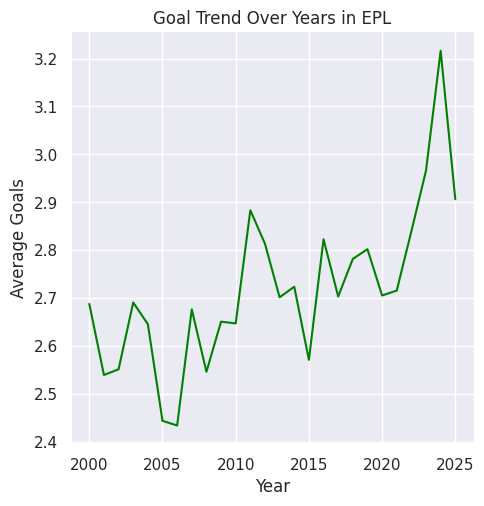

In [385]:
# We plot the trend of goals in the EPL

sns.relplot(data=df_e0, x='Year', y='Total Goals', kind='line', ci=None, color="green")
plt.title('Goal Trend Over Years in EPL')
plt.xlabel('Year')
plt.ylabel('Average Goals')

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)


Text(12.444444444444452, 0.5, 'Average Goals')

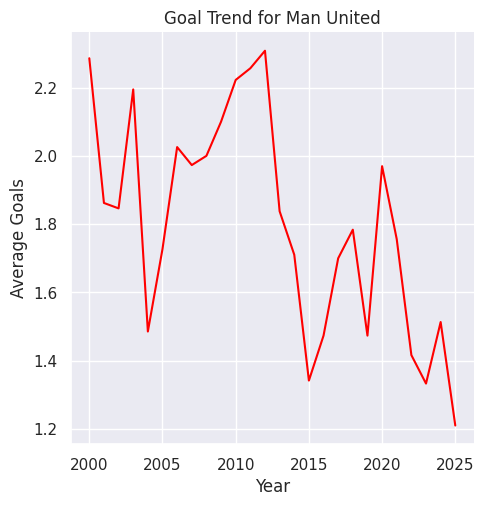

In [386]:
sns.relplot(data=df_manu, x='Year', y='ManUtdGoals', kind='line', ci=None, color='red')
plt.title('Goal Trend for Man United')
plt.xlabel('Year')
plt.ylabel('Average Goals')

* The average goals scored in Premier League games has seen a general upwards trend over the past 25 years
* The average goals scored by Manchester United has seen a decreasing trend over the past 25 years
* An especially noticeable dip in goals for Manchester United appears at around 2013, the time when Sir Alex left the club. This corroborates our findings regarding the ELO of Man United over the years.
* Though the premier league is seeing more goals in games lately, Manchester United cannot seem to get back to their scoring ways

# **Additional insights from  pandas**

We have used some pandas functions to aid our exploratory data analysis, however we will try to use of of these functions exclusively in the following section

# 1. Do home teams have an advantage?
We will calculate the win percentages of home teams and away teams and see if home teams win more on average

In [387]:
# We will continue using the df_exploratory dataset
# We see what portion of wins go to to different categories of teams (Home, Away, Draw)
outcome_counts = df_exploratory['FTResult'].value_counts(normalize=True) * 100
print(outcome_counts)

FTResult
H    45.489436
A    28.883150
D    25.627414
Name: proportion, dtype: float64


From the statistics above, it seems that home teams seem to have a higher percentage of wins than away teams. This may be due to due to home team support having an effect on a team's  performance

# 2. Has this home team advantage trend changed in the current years?

In [388]:
# We make use of query to see if the trend has developed lately

recent_df = df_exploratory.query('Year >= 2020')
outcome_counts_2 = recent_df['FTResult'].value_counts(normalize=True) * 100
print(outcome_counts_2)

FTResult
H    43.115453
A    31.798815
D    25.085732
Name: proportion, dtype: float64


It seems there is no significant difference in the scenario in recent years. However, the differences between home team wins and away team wins is slightly more balanced

# 3. Teams named United in EPL
* I was curious to see how many teams in the EPL have United in their name

In [389]:
# We make use of regex to search teams with United in their names

import re

united_pattern = re.compile(r'\bUnited\b')

# We use the df we subsetted only with EPL teams

united_teams = df_e0.loc[df_e0['HomeTeam'].str.contains(united_pattern), 'HomeTeam'].unique()
print(united_teams)

['Man United' 'Sheffield United']


It seems only 2 teams in the Dataset have United in their names. This is a disrepancy as more teams have United in their names. However, some of the teams do not have their full names in the dataset. For example: Newcastle United is called just Newcastle

# 4. Highest scoring games of Manchester United

* After looking at the bleak reality of Manchester United's current state. We will end this section of our analysis with the top 10 highest scoring games of Manchester United

In [390]:
df_manu['ManUtdGoals'].value_counts()
# This seems to reveal that although most of Man United's games are low scoring. We have a few that stand out.
# I will attempt to find those high scoring games in this part

,count
ManUtdGoals,
1,262
2,238
0,169
3,159
4,74
5,22
6,6
7,1
8,1


In [391]:
# We make use of where to create new columns containing opponent names and columns, this works a bit like the if statement

df_manu['Opponent'] = np.where(df_manu['HomeTeam'] == 'Man United', df_manu['AwayTeam'], df_manu['HomeTeam'])
df_manu['OpponentGoals'] = np.where(df_manu['HomeTeam'] == 'Man United', df_manu['FTAway'], df_manu['FTHome'])
top10manu = df_manu.sort_values('ManUtdGoals', ascending=False).head(10)[['MatchDate', 'ManUtdGoals', 'OpponentGoals', 'Opponent']]

/tmp/ipython-input-1471004326.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_manu['Opponent'] = np.where(df_manu['HomeTeam'] == 'Man United', df_manu['AwayTeam'], df_manu['HomeTeam'])
/tmp/ipython-input-1471004326.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_manu['OpponentGoals'] = np.where(df_manu['HomeTeam'] == 'Man United', df_manu['FTAway'], df_manu['FTHome'])


In [392]:
top10manu
# This looks messy, I will clean it up a bit

,MatchDate,ManUtdGoals,OpponentGoals,Opponent
179271,2021-02-02,9,0.0,Southampton
70257,2011-08-28,8,2.0,Arsenal
65170,2010-11-27,7,1.0,Blackburn
8960,2001-12-22,6,1.0,Southampton
177650,2020-12-20,6,2.0,Leeds
16289,2003-04-12,6,2.0,Newcastle
3691,2001-02-25,6,1.0,Arsenal
412,2000-09-05,6,0.0,Bradford
44809,2008-01-12,6,0.0,Newcastle
35152,2006-08-20,5,1.0,Fulham


In [393]:
top10manu['OpponentGoals'] = top10manu['OpponentGoals'].astype(int)
top10manu = top10manu.reset_index(drop=True)
top10manu.index = top10manu.index + 1  # Starting index from 1 to show the ranking by goals scored by Man United

print(top10manu)

    MatchDate  ManUtdGoals  OpponentGoals     Opponent
1  2021-02-02            9              0  Southampton
2  2011-08-28            8              2      Arsenal
3  2010-11-27            7              1    Blackburn
4  2001-12-22            6              1  Southampton
5  2020-12-20            6              2        Leeds
6  2003-04-12            6              2    Newcastle
7  2001-02-25            6              1      Arsenal
8  2000-09-05            6              0     Bradford
9  2008-01-12            6              0    Newcastle
10 2006-08-20            5              1       Fulham


* The largest margin Manchester United won by surprisingly happened in 2021, a time when Man United was not doinf too well. I remember watching the game and it was made possible by the fact that a Southampton  player picked up a red card in the first minutes of the game
* The second highest scoring game is iconic as well. It was when Man United beat one of their biggest rivals, Arsenal, who faced their heaviest league defeat since 1927. The scoreboard from the game pops up on the internet every now and then even today

# **Modeling (Done in 2 parts)**
* We are done with our exploratory analysis and our insights generated using pandas. Now we are going to further prepare our initial dataset for modeling

* Given the complexity of our dataset, we either have to **reduce features**, or **work with less rows** as the data contains information from multiple leagues across the world and all forms of data is not available for all the leagues

* We will explore both approaches (Prioritizing features vs prioritizing rows) and compare the models afterwards


# For the first section, we try to reduce features and preserve the number of data points

In [394]:
# In the exploratory analysis part, we filtered and took data for leagues which have data from a similar time period
# For modeling we won't need the element of time and thus we will include more leagues
# We exclude lower leagues as their results may not reflect top flight football

modeling_divisions = ['F1', 'F2', 'D1', 'D2', 'E1', 'N1', 'P1', 'E0', 'SP1', 'SP2', 'I1',
                        'I2','T1', 'E1','SC0', 'G1', 'USA', 'SWE', 'NOR', 'BRA', 'ARG',
                        'JAP', 'POL', 'DEN', 'SUI', 'FIN', 'IRL', 'MEX', 'CHN',
                        'RUS', 'ROM', 'AUT']

df_modeling = df[df['Division'].isin(modeling_divisions)]

In [395]:
df_modeling.shape

(174823, 38)

In [396]:
# Checking % of missing values
total_rows_modeling = len(df_modeling)
missing_data_modeling = df_modeling.isnull().sum()
missing_percentage_modeling = (missing_data_modeling / total_rows_modeling) * 100
missing_percentage_modeling

,0
Division,0.000000
MatchDate,0.000000
MatchTime,51.910218
HomeTeam,0.000000
AwayTeam,0.000000
HomeElo,25.327903
AwayElo,25.367944
Form3Home,0.000000
Form5Home,0.000000
Form3Away,0.000000


In [397]:
# We remove the MatchTime column as the time of the match is not related to the outcome and it has the most missing data
# We also drop some other unneccessary columns
# As we want to work with a high amount of datapoints, we drop some features with a lot of missing values
# We remove the Full time home and away goals columns as well because they would obviously predict the outcome regardless of having a model
columns_to_drop_modeling = ['MatchTime', 'MatchDate', 'Division', 'HomeTeam', 'AwayTeam',
                            'HomeShots', 'AwayShots', 'HomeTarget', 'AwayTarget', 'HomeFouls',
                            'AwayFouls', 'HomeCorners', 'AwayCorners', 'HomeYellow', 'AwayYellow',
                            'HomeRed', 'AwayRed', 'EloDiff', 'Form3Diff', 'Form5Diff', 'FTHome', 'FTAway']
df_modeling = df_modeling.drop(columns=columns_to_drop_modeling)

In [398]:
df_modeling.shape

(174823, 16)

In [399]:
# The remaining features we have are essential for our model as we want to see how betting odds, form, elo and other factors affect winning
# Thus we drop the remaining missing values
df_modeling_cleaned = df_modeling.dropna()

In [400]:
df_modeling_cleaned

,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,Form5Away,FTResult,HTHome,HTAway,HTResult,OddHome,OddDraw,OddAway,MaxHome,MaxDraw,MaxAway
27450,1720.28,1640.38,4.0,7.0,3.0,5.0,H,2.0,0.0,H,1.50,3.40,6.50,1.60,3.85,9.00
27451,1483.16,1479.83,5.0,6.0,1.0,3.0,H,1.0,0.0,H,2.00,2.75,3.80,2.20,2.85,4.30
27452,1509.24,1468.28,1.0,3.0,3.0,3.0,D,0.0,0.0,D,1.83,2.87,4.33,2.10,3.10,4.65
27453,1546.55,1616.84,6.0,12.0,3.0,9.0,D,0.0,0.0,D,2.50,2.75,2.75,2.60,2.90,3.10
27454,1449.70,1441.58,1.0,5.0,0.0,0.0,D,0.0,0.0,D,1.90,2.70,4.33,2.05,2.90,4.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230552,1339.21,1544.15,3.0,6.0,7.0,13.0,A,1.0,2.0,A,12.33,6.19,1.20,15.00,7.00,1.22
230553,1544.16,1433.67,4.0,10.0,1.0,3.0,H,1.0,0.0,H,1.22,6.23,10.97,1.24,6.75,13.00
230554,1473.67,1569.98,0.0,3.0,3.0,7.0,A,0.0,3.0,A,5.30,4.43,1.52,6.10,4.60,1.56
230555,1574.90,1525.76,7.0,13.0,6.0,9.0,H,2.0,1.0,H,1.68,3.14,6.31,1.72,3.25,7.20


In [401]:
# We change the categorical values in our target variable FTResult and do the same for the HTResult feature
# We change Home victories to 1 and draws and away victory to 0 as we want to preidct home wins

df_modeling_cleaned['FTResult'] = np.where(df_modeling_cleaned['FTResult'] == 'H', 1, 0)
df_modeling_cleaned['HTResult'] = np.where(df_modeling_cleaned['HTResult'] == 'H', 1, 0)

/tmp/ipython-input-3133263512.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modeling_cleaned['FTResult'] = np.where(df_modeling_cleaned['FTResult'] == 'H', 1, 0)
/tmp/ipython-input-3133263512.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modeling_cleaned['HTResult'] = np.where(df_modeling_cleaned['HTResult'] == 'H', 1, 0)


In [402]:
df_modeling_cleaned['FTResult'].value_counts()

,count
FTResult,
0,55191
1,44825


In [403]:
df_modeling_cleaned.isna().sum()

,0
HomeElo,0
AwayElo,0
Form3Home,0
Form5Home,0
Form3Away,0
Form5Away,0
FTResult,0
HTHome,0
HTAway,0
HTResult,0


# Train Test Split

In [404]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# **Our Target variable is FTResult which has 2 values 1 (Home team wins) and 0 (Home team draws or loses)**

In [405]:
# Modeling

features = ['HomeElo', 'AwayElo', 'Form3Home', 'Form5Home', 'Form3Away',
       'Form5Away', 'HTHome', 'HTAway','HTResult', 'OddHome', 'OddDraw',
       'OddAway', 'MaxHome', 'MaxDraw','MaxAway']
X = df_modeling_cleaned[features]
y = df_modeling_cleaned['FTResult']

# We scale the features between 0 and 1 for more coherent results
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)

In [406]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2,  stratify=y, random_state=42)

# Logistic Regression 1

In [407]:
lr_model = LogisticRegression(solver='newton-cholesky',
                              max_iter = 500)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=500, solver='newton-cholesky')

In [408]:
y_pred_lr = lr_model.predict(X_test)

In [409]:
conf_lr = confusion_matrix(y_test, y_pred_lr)

In [410]:
pd.DataFrame(conf_lr,
             index=['Actual 0', 'Actual 1'],
             columns=['Model 0', 'Model 1'])

,Model 0,Model 1
Actual 0,9246,1793
Actual 1,3214,5751


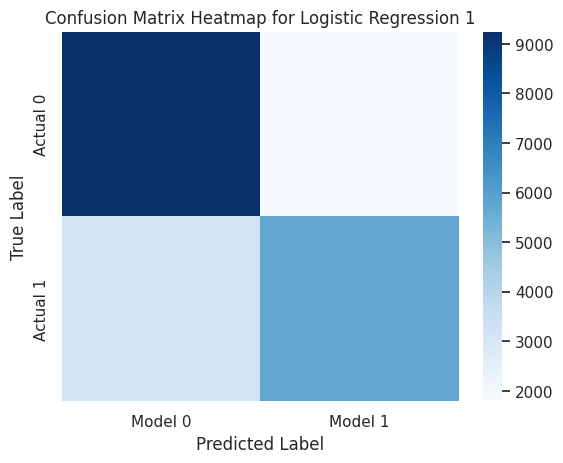

In [411]:
sns.heatmap(conf_lr, cmap='Blues', xticklabels=['Model 0', 'Model 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix Heatmap for Logistic Regression 1')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [412]:
#Performance Metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score
accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(y_test, y_pred_lr)

recall_lr = recall_score(y_test, y_pred_lr)

print('Accuracy is', accuracy_lr)
print('Precision is', precision_lr)
print('Recall is', recall_lr)

Accuracy is 0.7497000599880024
Precision is 0.7623276776246023
Recall is 0.641494701617401


In [413]:
# We have a look that at the model coefficients
coef_lr_df = pd.DataFrame(lr_model.coef_, columns=['HomeElo', 'AwayElo', 'Form3Home', 'Form5Home', 'Form3Away',
       'Form5Away', 'HTHome', 'HTAway','HTResult', 'OddHome', 'OddDraw',
       'OddAway', 'MaxHome', 'MaxDraw','MaxAway'], index=['Coefficients'])
coef_lr_df # Seems like HomeELo, HTHome and Odds play a big role

,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,Form5Away,HTHome,HTAway,HTResult,OddHome,OddDraw,OddAway,MaxHome,MaxDraw,MaxAway
Coefficients,1.071927,-0.971308,-0.01398,-0.010447,-0.131218,0.107229,8.911032,-8.70212,0.258572,-4.427601,1.153835,3.971837,-2.723006,0.413739,1.323742


In [414]:
X.columns

Index(['HomeElo', 'AwayElo', 'Form3Home', 'Form5Home', 'Form3Away',
       'Form5Away', 'HTHome', 'HTAway', 'HTResult', 'OddHome', 'OddDraw',
       'OddAway', 'MaxHome', 'MaxDraw', 'MaxAway'],
      dtype='object')

<Axes: >

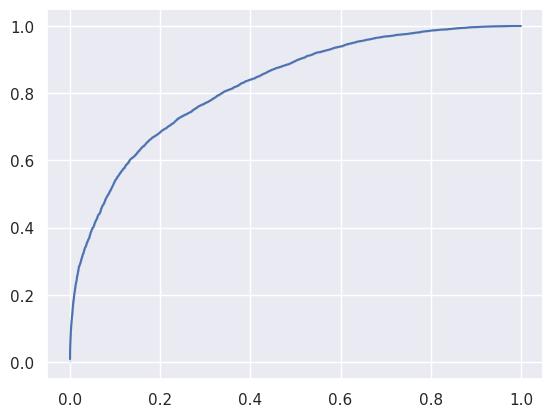

In [415]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba_lr = lr_model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr[:,1])
sns.lineplot(x=fpr, y=tpr)

In [416]:
# Area under curve
auc_score = roc_auc_score(y_test, y_pred_lr)
auc_score

np.float64(0.7395352844983462)

The results of the model could have been higher if we were able to use more features. We dropped some features containing match statistics like data related to shots on targets and fouls as they had a lot of missing values and using those would reduce our datapoints. But given the unpredictability of football, the results of the model are satisfactory.

# Support Vector Machine (SVM) 1

In [85]:
from sklearn.svm import SVC

svm_model = SVC ()
svm_model.fit (X_train, y_train)

SVC()

In [180]:
y_pred_svm = svm_model.predict(X_test)

In [181]:
#Performance Metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(y_test, y_pred_svm)

recall_svm = recall_score(y_test, y_pred_svm)

print('Accuracy is', accuracy_svm)
print('Precision is', precision_svm)
print('Recall is', recall_svm)

Accuracy is 0.7451509698060388
Precision is 0.7731317982765927
Recall is 0.6104852203011712


In [87]:
conf_svm = confusion_matrix(y_test, y_pred_svm)
pd.DataFrame(conf_svm, index=['Actual 0', 'Actual 1'],
             columns=['Model 0', 'Model 1'])

,Model 0,Model 1
Actual 0,9433,1606
Actual 1,3492,5473


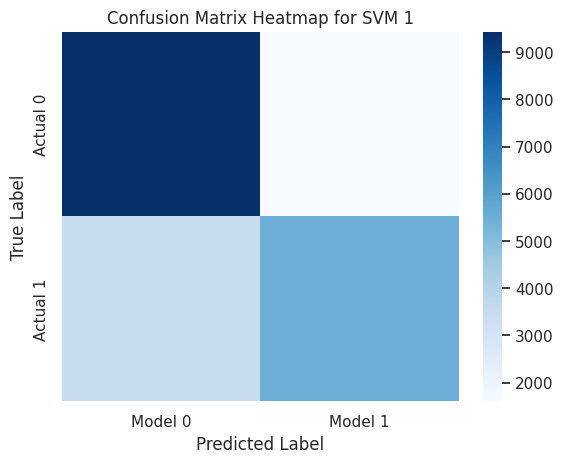

In [88]:
sns.heatmap(conf_svm, cmap='Blues', xticklabels=['Model 0', 'Model 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix Heatmap for SVM 1')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

SVM gives us similar but slightly lower accuracy when compared to logistic regression model. I initially ran both models without scaling the features and got around 65% accuracy on SVM. Scaling has brought significantly better results

# Decision Tree 1

In [417]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
clf = DecisionTreeClassifier(max_depth=7) #After trying a few, max depth of 7 gives best accuracy
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7)

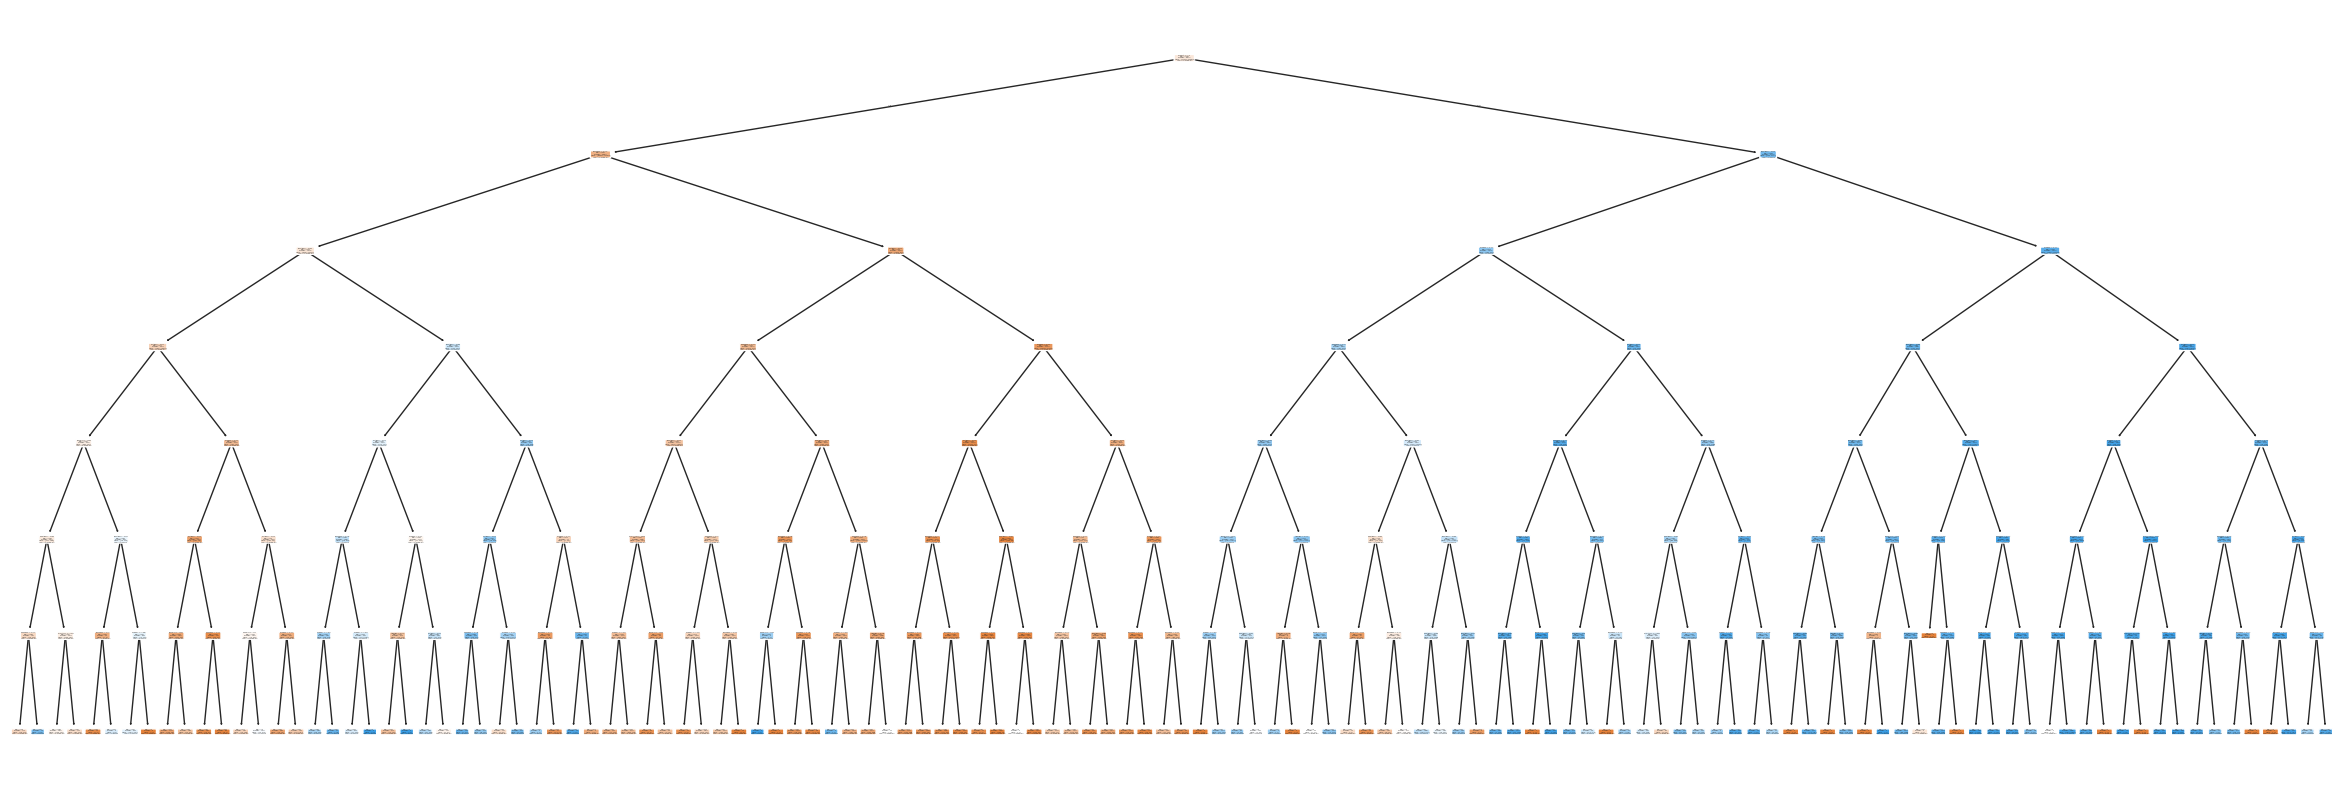

In [418]:
plt.figure(figsize=(30, 10))
plot_tree(clf, rounded=True, filled=True, feature_names=features, class_names={0:"No Home Win", 1:"Home Win"})
plt.show()

In [419]:
y_pred_clf = clf.predict(X_test)

In [420]:
#Performance Metrics
accuracy_clf = accuracy_score(y_test, y_pred_clf)

precision_clf = precision_score(y_test, y_pred_clf)

recall_clf = recall_score(y_test, y_pred_clf)

print('Accuracy is', accuracy_clf)
print('Precision is', precision_clf)
print('Recall is', recall_clf)

Accuracy is 0.7502999400119976
Precision is 0.7540962621607783
Recall is 0.6571109871723368


In [421]:
conf_clf = confusion_matrix(y_test, y_pred_clf)
pd.DataFrame(conf_clf, index=['Actual 0', 'Actual 1'],
             columns=['Model 0', 'Model 1'])

,Model 0,Model 1
Actual 0,9118,1921
Actual 1,3074,5891


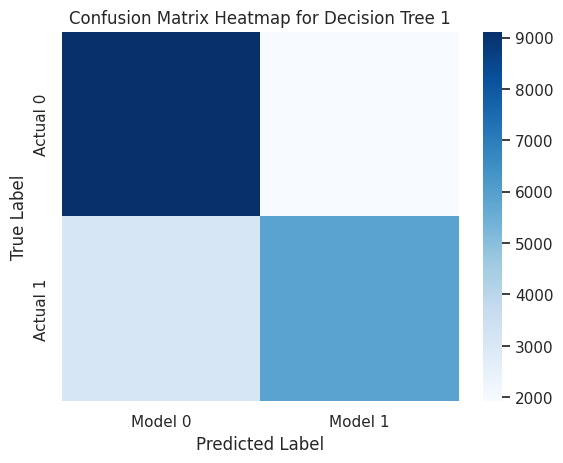

In [422]:
sns.heatmap(conf_clf, cmap='Blues', xticklabels=['Model 0', 'Model 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix Heatmap for Decision Tree 1')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The decision tree model gives us similar performance to the previous models

**Summary of models so far**

* In preparing the dataset for the models above, we tried to include as many rows of data as possible and ended up with around 100,000 rows of data. However, we did have to get rid of a lot of features to deal with missing values.

* This model has predictive capabilities as most of the feautures here are available before the game. Only the Half time home and away goals feature will be available at half time of the game. So essentially, this model can predict at halftime if the home team will win the game or not at the end with around 75% accuracy across all 3 models.

# Random Forest 1
* We run an additional model to see if we can improve overfitting issues within a decision tree

In [424]:
from sklearn.ensemble import RandomForestClassifier

rf_model_1 = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model_1.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [425]:
y_pred_rf_1 = rf_model_1.predict(X_test)

In [426]:
conf_matrix_rf_1 = confusion_matrix(y_test, y_pred_rf_1)

In [427]:
pd.DataFrame(conf_matrix_rf_1, index=['Actual 0', 'Actual 1'],
             columns=['Model 0', 'Model 1'])

,Model 0,Model 1
Actual 0,8996,2043
Actual 1,3100,5865


In [428]:
#Performance Metrics
accuracy_rf_1 = accuracy_score(y_test, y_pred_rf_1)

precision_rf_1 = precision_score(y_test, y_pred_rf_1)

recall_rf_1 = recall_score(y_test, y_pred_rf_1)

print('Accuracy is', accuracy_rf_1)
print('Precision is', precision_rf_1)
print('Recall is', recall_rf_1)

Accuracy is 0.7429014197160568
Precision is 0.7416540212443096
Recall is 0.6542108198549916


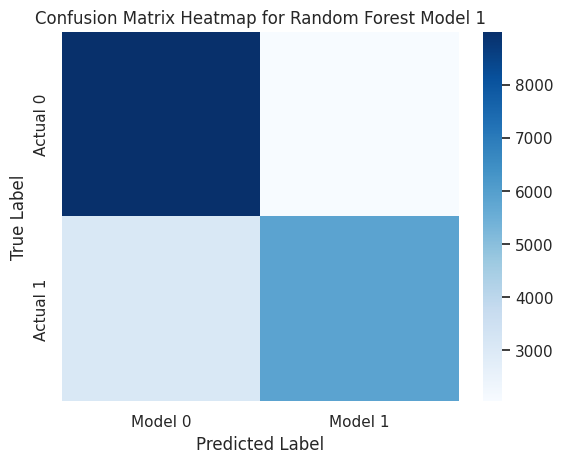

In [429]:
sns.heatmap(conf_matrix_rf_1, cmap='Blues', xticklabels=['Model 0', 'Model 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix Heatmap for Random Forest Model 1')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

* We run an additional Random Forest Model to see if the Decision Tree has overfitting issues that can be solved thorugh this model, but the random forest has sligthly worse performance in this case

* Across all 4 models, though the accuracy and precision values are at around 75%, the models struggle a bit more when it comes to recall

# Now we try to keep as many features as possible
* We will run the models again with newly cleaned datasets with as many feautes as possible

In [430]:
# We try to include as many relevant leagues as possible
modeling_divisions_2 = ['F1', 'F2', 'D1', 'D2', 'E1', 'N1', 'P1', 'E0', 'SP1', 'SP2', 'I1',
                        'I2','T1', 'E1','SC0', 'G1', 'USA', 'SWE', 'NOR', 'BRA', 'ARG',
                        'JAP', 'POL', 'DEN', 'SUI', 'FIN', 'IRL', 'MEX', 'CHN',
                        'RUS', 'ROM', 'AUT']

df_modeling_2 = df[df['Division'].isin(modeling_divisions_2)]

In [431]:
# We remove a few redundant and unnecessary columns

columns_to_drop_modeling_2 = ['MatchTime', 'MatchDate', 'Division', 'HomeTeam', 'AwayTeam',
                             'EloDiff', 'Form3Diff', 'Form5Diff', 'FTHome', 'FTAway']
df_modeling_2 = df_modeling_2.drop(columns=columns_to_drop_modeling_2)

In [432]:
df_modeling_2.shape

(174823, 28)

In [433]:
total_rows_modeling_2 = len(df_modeling_2)
missing_data_modeling_2 = df_modeling_2.isnull().sum()
missing_percentage_modeling_2 = (missing_data_modeling_2 / total_rows_modeling_2) * 100
missing_percentage_modeling_2

,0
HomeElo,25.327903
AwayElo,25.367944
Form3Home,0.000000
Form5Home,0.000000
Form3Away,0.000000
Form5Away,0.000000
FTResult,0.000000
HTHome,30.595517
HTAway,30.595517
HTResult,30.595517


In [434]:
# We have already narrowed down the important features. As we are going to focus on features we drop the null values this time
df_modeling_2_cleaned = df_modeling_2.dropna()

In [435]:
df_modeling_2_cleaned['FTResult'] = np.where(df_modeling_2_cleaned['FTResult'] == 'H', 1, 0)
df_modeling_2_cleaned['HTResult'] = np.where(df_modeling_2_cleaned['HTResult'] == 'H', 1, 0)

df_modeling_2_cleaned

/tmp/ipython-input-1651745021.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modeling_2_cleaned['FTResult'] = np.where(df_modeling_2_cleaned['FTResult'] == 'H', 1, 0)
/tmp/ipython-input-1651745021.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modeling_2_cleaned['HTResult'] = np.where(df_modeling_2_cleaned['HTResult'] == 'H', 1, 0)


,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,Form5Away,FTResult,HTHome,HTAway,HTResult,...,HomeYellow,AwayYellow,HomeRed,AwayRed,OddHome,OddDraw,OddAway,MaxHome,MaxDraw,MaxAway
27468,1326.40,1405.42,7.0,10.0,3.0,7.0,0,1.0,0.0,1,...,1.0,0.0,0.0,0.0,2.50,3.20,2.50,2.70,3.35,2.65
27470,1412.61,1304.96,4.0,10.0,1.0,2.0,0,0.0,1.0,0,...,2.0,3.0,1.0,0.0,1.61,3.40,5.00,1.63,3.65,6.40
27471,1357.64,1437.43,4.0,4.0,2.0,5.0,0,1.0,1.0,0,...,5.0,1.0,0.0,0.0,2.62,3.20,2.37,2.65,3.35,2.60
27472,1382.94,1688.65,2.0,5.0,6.0,9.0,0,1.0,3.0,0,...,2.0,2.0,0.0,0.0,7.50,4.00,1.44,9.00,5.00,1.44
27473,1663.18,1304.03,3.0,9.0,4.0,5.0,1,1.0,0.0,1,...,0.0,2.0,0.0,1.0,1.14,6.50,21.00,1.15,9.00,23.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230552,1339.21,1544.15,3.0,6.0,7.0,13.0,0,1.0,2.0,0,...,3.0,1.0,0.0,0.0,12.33,6.19,1.20,15.00,7.00,1.22
230553,1544.16,1433.67,4.0,10.0,1.0,3.0,1,1.0,0.0,1,...,1.0,5.0,0.0,0.0,1.22,6.23,10.97,1.24,6.75,13.00
230554,1473.67,1569.98,0.0,3.0,3.0,7.0,0,0.0,3.0,0,...,2.0,2.0,0.0,0.0,5.30,4.43,1.52,6.10,4.60,1.56
230555,1574.90,1525.76,7.0,13.0,6.0,9.0,1,2.0,1.0,1,...,0.0,1.0,0.0,0.0,1.68,3.14,6.31,1.72,3.25,7.20


In [436]:
df_modeling_2_cleaned.shape

(69137, 28)

This time we have more features and lower number of rows

# Train test Split 2

In [437]:
# Modeling part 2

features_2 = ['HomeElo', 'AwayElo', 'Form3Home', 'Form5Home', 'Form3Away',
       'Form5Away', 'HTHome', 'HTAway', 'HTResult', 'HomeShots',
       'AwayShots', 'HomeTarget', 'AwayTarget', 'HomeFouls', 'AwayFouls',
       'HomeCorners', 'AwayCorners', 'HomeYellow', 'AwayYellow', 'HomeRed',
       'AwayRed', 'OddHome', 'OddDraw', 'OddAway', 'MaxHome', 'MaxDraw',
       'MaxAway']
X_2 = df_modeling_2_cleaned[features_2]
y_2 = df_modeling_2_cleaned['FTResult']

# We scale the features between 0 and 1 for more coherent results
scaler_2 = MinMaxScaler(feature_range=(0, 1))
X_scaled_2 = scaler_2.fit_transform(X_2)

In [438]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_scaled_2, y_2, test_size=0.2,  stratify=y_2, random_state=42)

# Logistic Regression 2

In [439]:
lr_model_2 = LogisticRegression(solver='newton-cholesky',
                              max_iter = 500)
lr_model_2.fit(X_train_2, y_train_2)
y_pred_lr_2 = lr_model_2.predict(X_test_2)

In [440]:
conf_lr_2 = confusion_matrix(y_test_2, y_pred_lr_2)

In [441]:
pd.DataFrame(conf_lr_2,
             index=['Actual 0', 'Actual 1'],
             columns=['Model 0', 'Model 1'])

,Model 0,Model 1
Actual 0,6412,1276
Actual 1,1714,4426


In [442]:
accuracy_lr_2 = accuracy_score(y_test_2, y_pred_lr_2)
accuracy_lr_2

0.7837720566965577

In [443]:
#Performance Metrics
accuracy_lr_2 = accuracy_score(y_test_2, y_pred_lr_2)

precision_lr_2 = precision_score(y_test_2, y_pred_lr_2)

recall_lr_2 = recall_score(y_test_2, y_pred_lr_2)

print('Accuracy is', accuracy_lr_2)
print('Precision is', precision_lr_2)
print('Recall is', recall_lr_2)

Accuracy is 0.7837720566965577
Precision is 0.7762188705717292
Recall is 0.7208469055374593


In [444]:
# We have a look that at the model coefficients
coef_lr_df_2 = pd.DataFrame(lr_model_2.coef_, columns=['HomeElo', 'AwayElo', 'Form3Home', 'Form5Home', 'Form3Away',
       'Form5Away', 'HTHome', 'HTAway', 'HTResult', 'HomeShots',
       'AwayShots', 'HomeTarget', 'AwayTarget', 'HomeFouls', 'AwayFouls',
       'HomeCorners', 'AwayCorners', 'HomeYellow', 'AwayYellow', 'HomeRed',
       'AwayRed', 'OddHome', 'OddDraw', 'OddAway', 'MaxHome', 'MaxDraw',
       'MaxAway'], index=['Coefficients'])
print(coef_lr_df_2) #Home and Away red seem to affect outcomes

               HomeElo   AwayElo  Form3Home  Form5Home  Form3Away  Form5Away  \
Coefficients  1.081019 -0.865467  -0.060629   0.039298  -0.088993  -0.101634   

                HTHome    HTAway  HTResult  HomeShots  ...  HomeYellow  \
Coefficients  7.754385 -7.568266  0.302035   -1.94579  ...   -0.048379   

              AwayYellow   HomeRed  AwayRed   OddHome   OddDraw   OddAway  \
Coefficients   -0.114927 -2.163981  5.47292 -3.204172  1.446333  2.673114   

               MaxHome   MaxDraw   MaxAway  
Coefficients -1.762889  0.262516  0.425579  

[1 rows x 27 columns]


<Axes: >

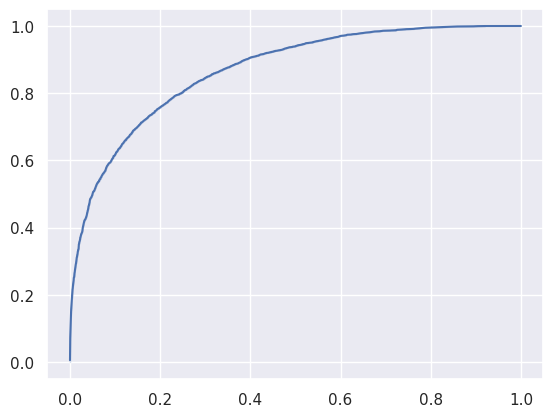

In [445]:
y_proba_lr_2 = lr_model_2.predict_proba(X_test_2)
fpr, tpr, thresholds = roc_curve(y_test_2, y_proba_lr_2[:,1])
sns.lineplot(x=fpr, y=tpr)

In [446]:
# Area under curve 2
auc_score_2 = roc_auc_score(y_test_2, y_pred_lr_2)
auc_score_2

np.float64(0.7774369803441719)

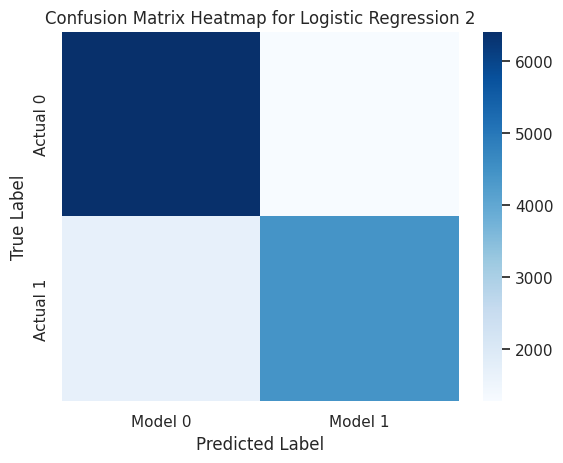

In [447]:
sns.heatmap(conf_lr_2, cmap='Blues', xticklabels=['Model 0', 'Model 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix Heatmap for Logistic Regression 2')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The model here has better performance with improved values accross all metrics

# SVM 2

In [448]:
svm_model_2 = SVC ()
svm_model_2.fit (X_train_2, y_train_2)

SVC()

In [449]:
y_pred_svm_2 = svm_model_2.predict(X_test_2)


In [450]:
#Performance Metrics
accuracy_svm_2 = accuracy_score(y_test_2, y_pred_svm_2)

precision_svm_2 = precision_score(y_test_2, y_pred_svm_2)

recall_svm_2 = recall_score(y_test_2, y_pred_svm_2)

print('Accuracy is', accuracy_svm_2)
print('Precision is', precision_svm_2)
print('Recall is', recall_svm_2)

Accuracy is 0.7741538906566388
Precision is 0.7753239642270487
Recall is 0.6918566775244299


In [451]:
conf_svm_2 = confusion_matrix(y_test_2, y_pred_svm_2)
pd.DataFrame(conf_svm_2, index=['Actual 0', 'Actual 1'],
             columns=['Model 0', 'Model 1'])

,Model 0,Model 1
Actual 0,6457,1231
Actual 1,1892,4248


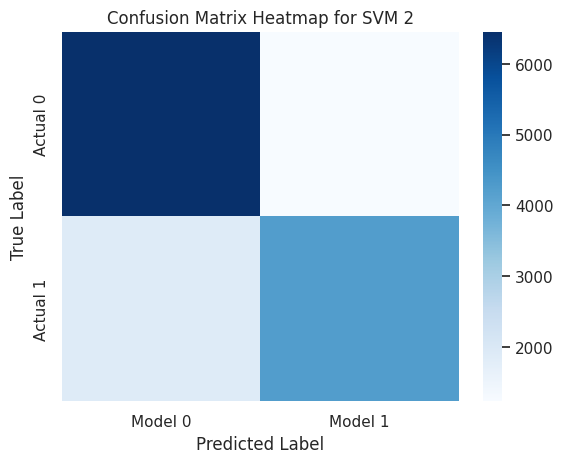

In [452]:
sns.heatmap(conf_svm_2, cmap='Blues', xticklabels=['Model 0', 'Model 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix Heatmap for SVM 2')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Decision Tree 2

In [453]:
clf_2 = DecisionTreeClassifier(max_depth=7)
clf_2.fit(X_train_2, y_train_2)

DecisionTreeClassifier(max_depth=7)

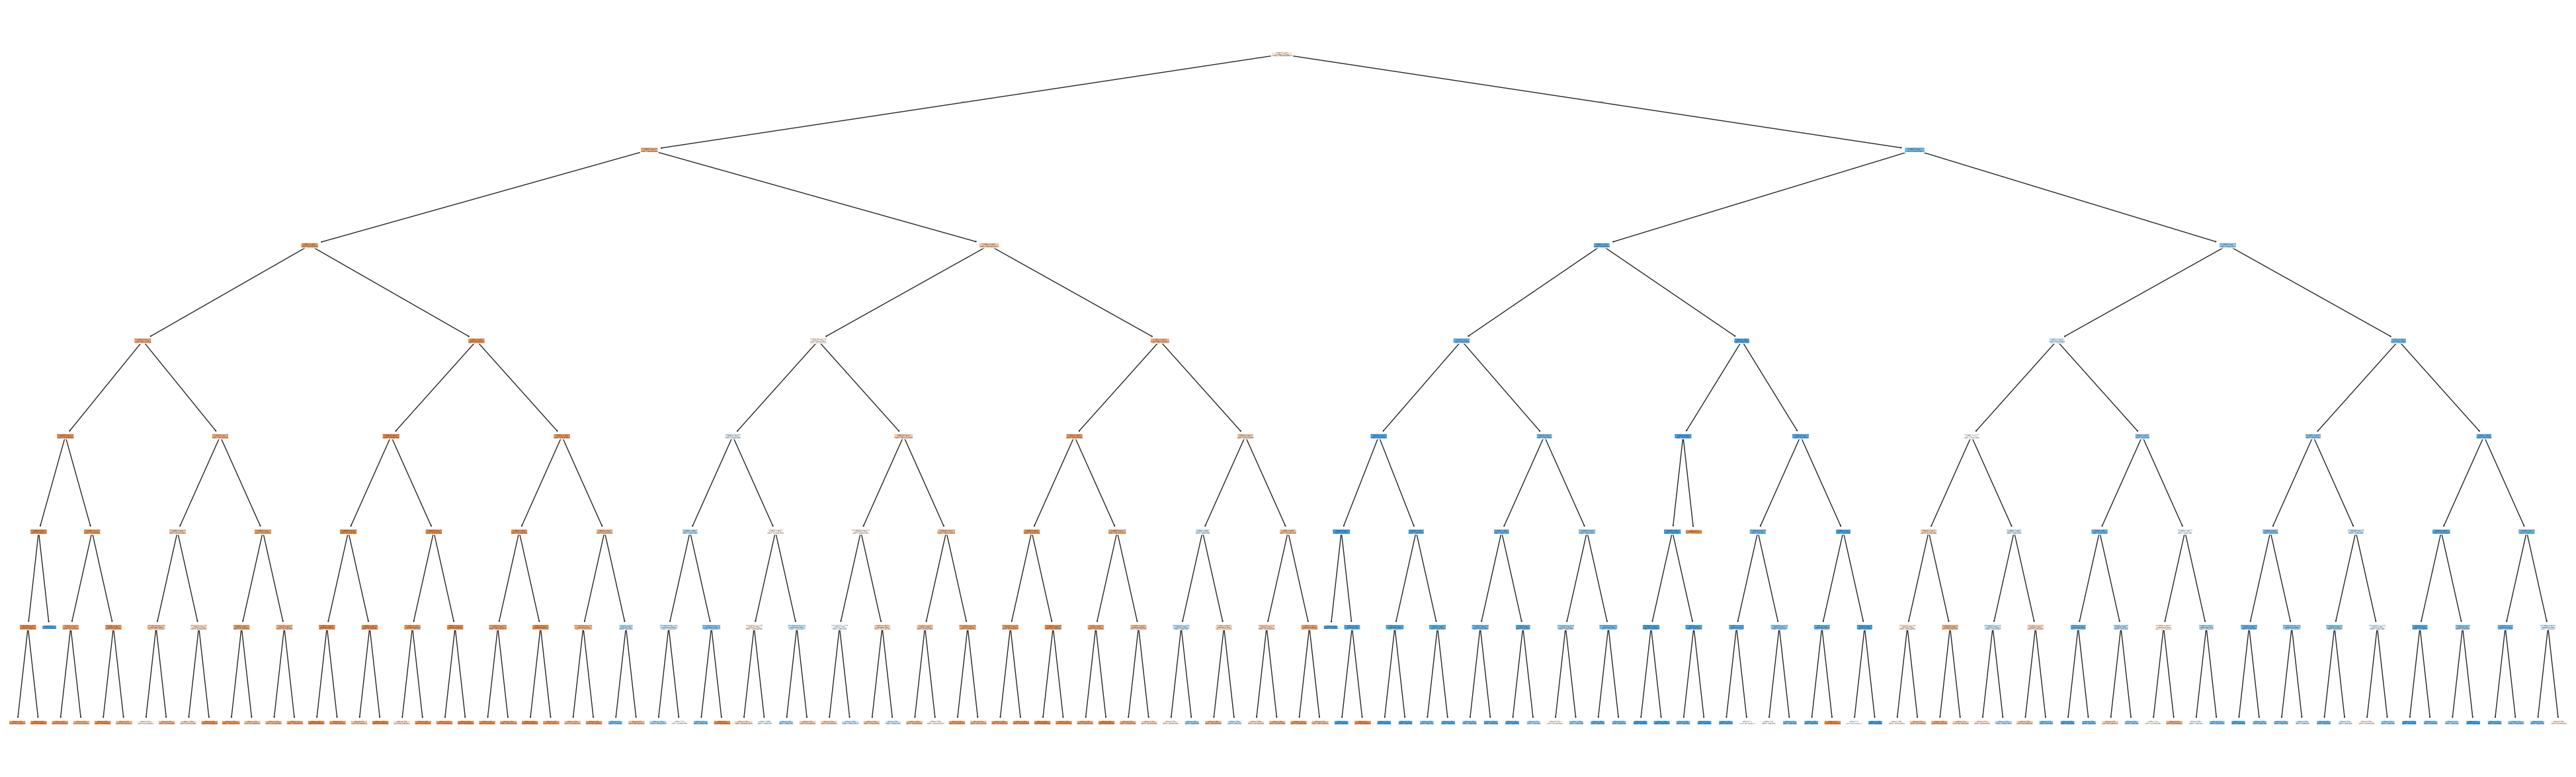

In [454]:
plt.figure(figsize=(50,15))
plot_tree(clf_2, rounded=True, filled=True, feature_names=features_2, class_names={0:"No Home Win", 1:"Home Win"})
plt.show()

In [455]:
y_pred_clf_2 = clf_2.predict(X_test_2)
accuracy_clf_2 = accuracy_score(y_test_2, y_pred_clf_2)
accuracy_clf_2

0.7633063349725195

In [456]:
#Performance Metrics
accuracy_clf_2 = accuracy_score(y_test_2, y_pred_clf_2)

precision_clf_2 = precision_score(y_test_2, y_pred_clf_2)

recall_clf_2 = recall_score(y_test_2, y_pred_clf_2)

print('Accuracy is', accuracy_clf_2)
print('Precision is', precision_clf_2)
print('Recall is', recall_clf_2)

Accuracy is 0.7633063349725195
Precision is 0.7679940175733782
Recall is 0.6690553745928339


In [457]:
conf_clf_2 = confusion_matrix(y_test_2, y_pred_clf_2)
pd.DataFrame(conf_clf_2, index=['Actual 0', 'Actual 1'],
             columns=['Model 0', 'Model 1'])

,Model 0,Model 1
Actual 0,6447,1241
Actual 1,2032,4108


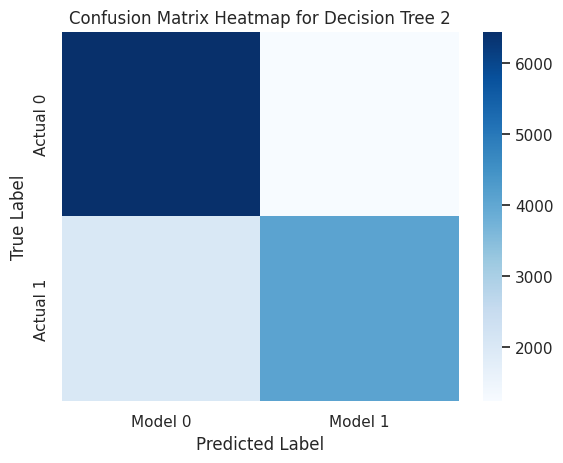

In [458]:
sns.heatmap(conf_clf_2, cmap='Blues', xticklabels=['Model 0', 'Model 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix Heatmap for Decision Tree 2')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Summary of models in the second part**

* The models here perform better even with lesser training data as we have more relevant features here.
* However, the models in this section lack the predictive capabilities of the initial set of models as here we have to make use of statistics like shots on target and cards received by each team within the game.
* Though this model cannot predict outcome, this is better at explaining how different statistics affect the outcome of a game

# Random Forest 2

We run a random forest model here as well

In [459]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model.fit(X_train_2, y_train_2)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [460]:
y_pred_rf = rf_model.predict(X_test_2)

In [461]:
conf_matrix_rf = confusion_matrix(y_test_2, y_pred_rf)

In [462]:
pd.DataFrame(conf_matrix_rf, index=['Actual 0', 'Actual 1'],
             columns=['Model 0', 'Model 1'])

,Model 0,Model 1
Actual 0,6425,1263
Actual 1,1854,4286


In [463]:
#Performance Metrics
accuracy_rf = accuracy_score(y_test_2, y_pred_rf)

precision_rf = precision_score(y_test_2, y_pred_rf)

recall_rf = recall_score(y_test_2, y_pred_rf)

print('Accuracy is', accuracy_rf)
print('Precision is', precision_rf)
print('Recall is', recall_rf)

Accuracy is 0.7745877928840035
Precision is 0.7723914218778158
Recall is 0.6980456026058632


To deal with overfitting issues of the decision tree model, we run an additional random forest model with our better performing dataset. This model performs better than our second decision tree on all metrics

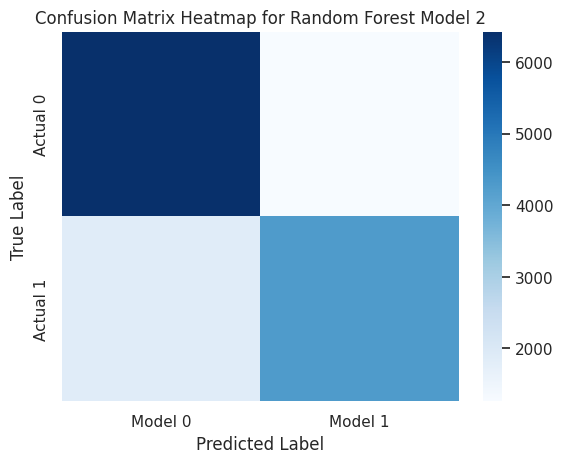

In [464]:
sns.heatmap(conf_matrix_rf, cmap='Blues', xticklabels=['Model 0', 'Model 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix Heatmap for Random Forest Model 2')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The heatmap of confusion matrix shows that the most of the predicted values of the model align with the actual data